# 05 — CHIRPS Rainfall Signal: L3 Backtest (SPI rebuild)

Validates the L3 climate signal: a **dry flowering season** (Sep–Nov) over **Minas Gerais**,
Brazil's primary Arabica state, threatens the *next* crop and is bullish for Arabica price
~12–18 months later (flowering → cherry set → harvest → price adjustment).

**What changed in this rebuild (per desk review):**

1. **Standardized Precipitation Index (SPI)** replaces the raw `rain − historical_mean`
   anomaly. SPI is a probabilistic, gamma-fit z-score: SPI ≈ −1.5 is roughly a
   1-in-15-year drought *for that month/season*, so it is comparable across the wet and
   dry parts of the year in a way that raw millimetres are not (−100 mm in dry September
   is catastrophic; −100 mm in wet December is a rounding error).
2. **Cumulative flowering-season deficit** — the primary feature is now the **SPI-3
   accumulation ending November** (the whole Sep–Oct–Nov flowering window in one number),
   plus the reviewer's monthly-SPI-sum variant. We target only the flowering window, not
   all 12 months, because that is the price-relevant mechanism.
3. **Annual crop-year frame is primary.** Monthly Pearson r dilutes a signal that is
   concentrated in one 3-month window per year; the annual test is where L3 lives.
4. **Robustness controls added:** an *expanding-window* SPI (no look-ahead) and a
   *partial correlation controlling for stocks-to-use* (a drought bites harder when the
   global buffer is thin).

**Gate (L3, redefined).** L3 is a *confirming* amplifier, not a standalone timing signal,
so it is evaluated on the annual frame: r(flowering SPI-3 deficit, forward-12m price change)
**≥ +0.30**. This mirrors the notebook-02 (ENSO) and notebook-04 (S/U) gate redefinitions
where the original monthly/YoY lens was shown to be the wrong frame. The old gate
(monthly r ≥ +0.12) is still reported for continuity.

Uses Google Earth Engine when `EARTHENGINE_PROJECT` is set; otherwise falls back to the
cached raw-precip CSV so the notebook is runnable without GEE credentials.

## Sec 0  Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')

from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from dotenv import load_dotenv  # noqa: E402
from scipy import stats  # noqa: E402

load_dotenv('../../.env')
os.makedirs('data', exist_ok=True)

In [2]:
from domains.coffee.sources.chirps import is_flowering_month  # noqa: E402

## Sec 1  Fetch CHIRPS Data

Monthly area-mean rainfall over the Minas Gerais GAUL polygon. Prefer a live GEE fetch;
fall back to the cached raw-precip CSV (deterministic CHIRPS output) when GEE auth is
absent so the analysis is reproducible without credentials.

In [3]:
START = date(2008, 1, 1)
END   = date(2025, 12, 31)
CACHE = 'data/chirps_minas_monthly.csv'

rain = None
proj = os.environ.get('EARTHENGINE_PROJECT')
if proj:
    try:
        from domains.coffee.sources.chirps import fetch
        obs, run = fetch(START, END)
        if run.status.name == 'SUCCESS' and obs:
            rain = pd.DataFrame(
                [{'date': o.observed_date, 'precip': o.value} for o in obs]
            ).set_index('date')
            print(f'Fetched via GEE: {run.records_fetched} months '
                  f'({run.status.name})')
    except Exception as exc:  # noqa: BLE001
        print(f'GEE unavailable ({str(exc)[:70]}); using cache.')

if rain is None:
    rain = pd.read_csv(CACHE, parse_dates=['date'], index_col='date')[['precip']]
    print(f'Loaded cached raw CHIRPS precip: {len(rain)} months (no GEE this run)')

rain.index = pd.to_datetime(rain.index)
rain = rain.sort_index()[['precip']]
print(f'CHIRPS: {len(rain)} months, {rain.index[0].date()} to {rain.index[-1].date()}')
print(f'Monthly rainfall range: [{rain["precip"].min():.1f}, {rain["precip"].max():.1f}] mm')
rain.tail(4)

Loaded cached raw CHIRPS precip: 216 months (no GEE this run)
CHIRPS: 216 months, 2008-01-31 to 2025-12-31
Monthly rainfall range: [4.4, 353.6] mm


,precip
date,
2025-09-30,24.239667
2025-10-31,53.344611
2025-11-30,149.655065
2025-12-31,210.600087


## Sec 2  Data Quality + Seasonality

In [4]:
core = rain['precip'].loc['2010-01-01':'2024-12-31']
assert core.notna().all(), 'NaN in rainfall over core window'
assert (core >= 0).all(), 'negative rainfall'
print('Rainfall non-NaN and non-negative over 2010-2024: OK')

clim = rain.groupby(rain.index.month)['precip'].mean()
print('\nClimatology (mean mm by month) — expect wet Nov-Mar, dry Jun-Aug:')
for mth in range(1, 13):
    flag = ' <- flowering' if is_flowering_month(mth) else ''
    print(f'  {mth:2d}: {clim[mth]:6.1f} mm{flag}')

Rainfall non-NaN and non-negative over 2010-2024: OK

Climatology (mean mm by month) — expect wet Nov-Mar, dry Jun-Aug:
   1:  207.6 mm
   2:  148.7 mm
   3:  150.2 mm
   4:   68.5 mm
   5:   23.3 mm
   6:   10.9 mm
   7:    8.3 mm
   8:    9.4 mm
   9:   29.5 mm <- flowering
  10:  102.2 mm <- flowering
  11:  191.2 mm <- flowering
  12:  237.3 mm


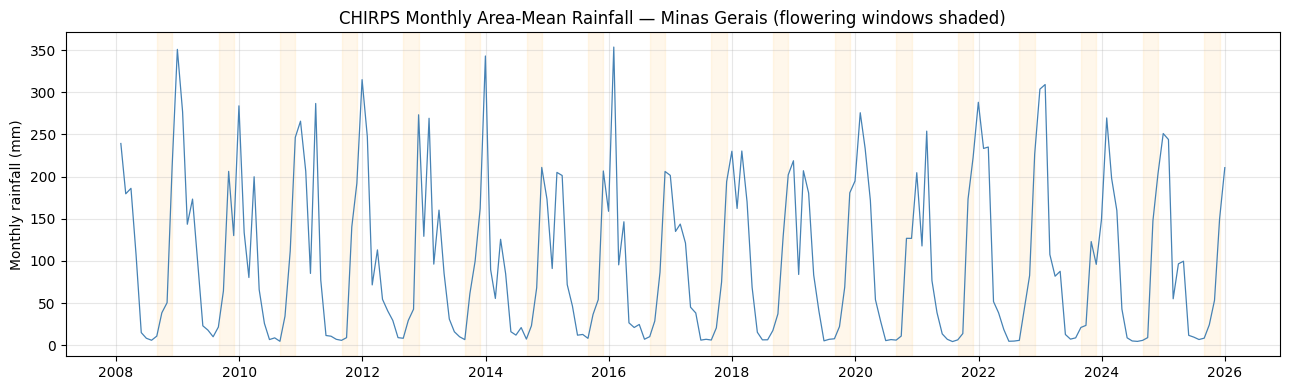

Saved: data/05_rainfall.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(rain.index, rain['precip'], color='steelblue', lw=0.9)
for yr in range(2008, 2026):
    ax.axvspan(pd.Timestamp(f'{yr}-09-01'), pd.Timestamp(f'{yr}-11-30'),
               color='orange', alpha=0.08)
ax.set_ylabel('Monthly rainfall (mm)')
ax.set_title('CHIRPS Monthly Area-Mean Rainfall — Minas Gerais (flowering windows shaded)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/05_rainfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_rainfall.png')

## Sec 3  SPI Feature Engineering

**Standardized Precipitation Index.** For a given accumulation window we fit a gamma
distribution to the historical precipitation totals, map each observation through the
gamma CDF, then to a standard-normal z-score. Zero-precip months are handled with the
usual mixed-distribution correction (probability mass `q` at zero). Interpretation:

| SPI | Meaning |
|-----|---------|
| 0 | median rainfall |
| −1.0 | ~1-in-6 dry |
| −1.5 | ~1-in-15 dry (severe) |
| −2.0 | ~1-in-40 dry (extreme) |

We build two flowering-season measures:
- **SPI-3 ending November** — one number for the whole Sep+Oct+Nov accumulation (primary).
- **Monthly-SPI deficit** — the reviewer's `−Σ min(SPI_month, 0)` over Sep, Oct, Nov (variant).

In [6]:
def spi_from_gamma(value, fit_values):
    """Standardized Precipitation Index: map `value` to a z-score using a gamma
    fitted on `fit_values` (with a zero-precip probability correction)."""
    fit = np.asarray(fit_values, dtype=float)
    fit = fit[~np.isnan(fit)]
    pos = fit[fit > 0]
    q = float((fit <= 0).sum()) / len(fit)          # prob of zero precip
    if len(pos) < 4 or pos.std() == 0:              # too little to fit a gamma
        mu, sd = fit.mean(), (fit.std(ddof=0) or 1.0)
        return float((value - mu) / sd)
    a, loc, scale = stats.gamma.fit(pos, floc=0)
    cdf = q + (1 - q) * stats.gamma.cdf(value, a, loc=loc, scale=scale)
    return float(stats.norm.ppf(np.clip(cdf, 1e-6, 1 - 1e-6)))


# SPI-3 accumulation ending each month (rolling 3-month sum, standardized per end-month)
rain['acc3'] = rain['precip'].rolling(3).sum()
spi3 = pd.Series(index=rain.index, dtype=float)
for mth in range(1, 13):
    block = rain[rain.index.month == mth]
    fitv = block['acc3'].dropna().values
    spi3.loc[block.index] = [
        spi_from_gamma(v, fitv) if not np.isnan(v) else np.nan for v in block['acc3']
    ]
rain['spi3'] = spi3

# Monthly SPI-1 (per calendar month) for the reviewer's cumulative-deficit variant
spi1 = pd.Series(index=rain.index, dtype=float)
for mth in range(1, 13):
    block = rain[rain.index.month == mth]
    spi1.loc[block.index] = [spi_from_gamma(v, block['precip'].values) for v in block['precip']]
rain['spi1'] = spi1

print('SPI-3 sanity — mean ~0, std ~1 over full sample:')
print(f'  SPI-3: mean={rain["spi3"].mean():+.2f}  std={rain["spi3"].std():.2f}')

SPI-3 sanity — mean ~0, std ~1 over full sample:
  SPI-3: mean=-0.00  std=1.00


## Sec 4  Flowering-Season Deficit Feature

The flowering signal is **asymmetric**: a dry flowering season is a supply shock (bullish),
but a wet one does not symmetrically crash prices. So the composite input is the *deficit* —
the drought side only:

- `flowering_spi3` = SPI-3 ending November (signed; negative = dry).
- `flowering_drought` = `max(0, −flowering_spi3)` — the clamped deficit fed to the composite.
- `monthly_deficit` = `−Σ min(SPI1_m, 0)` over Sep–Nov (reviewer's variant).

In [7]:
# Annual (crop-year) flowering features, keyed by year
nov_spi3 = rain['spi3'][rain.index.month == 11]
nov_spi3.index = nov_spi3.index.year
flowering_spi3 = nov_spi3.rename('flowering_spi3')
flowering_drought = np.maximum(0.0, -flowering_spi3).rename('flowering_drought')

fl1 = rain['spi1'][rain.index.month.isin([9, 10, 11])]
monthly_deficit = (
    fl1.groupby(fl1.index.year).apply(lambda s: -np.minimum(s, 0).sum())
).rename('monthly_deficit')

annual = pd.concat([flowering_spi3, flowering_drought, monthly_deficit], axis=1)
print('Annual flowering features (signed SPI-3; deficit forms):')
print(annual.round(2).to_string())
print('\nDriest flowering seasons (most negative SPI-3):')
print(flowering_spi3.sort_values().head(5).round(2).to_dict())

Annual flowering features (signed SPI-3; deficit forms):
      flowering_spi3  flowering_drought  monthly_deficit
date                                                    
2008           -0.38               0.38             1.31
2009            1.43               0.00             1.42
2010            1.30               0.00            -0.00
2011            0.40               0.00             1.67
2012            0.48               0.00             1.61
2013            0.06               0.00             0.58
2014           -0.35               0.35             0.98
2015           -0.45               0.45             1.18
2016            0.03               0.00             0.23
2017           -0.61               0.61             0.99
2018            0.88               0.00            -0.00
2019           -0.97               0.97             1.18
2020           -1.13               1.13             2.93
2021            1.58               0.00             1.07
2022            0.60           

## Sec 5  Annual Signal vs Forward Price (primary)

Flowering-season signal in year *Y* vs the Arabica price change over the following 12 months
(Nov *Y* → Nov *Y+1*) — the window in which the short crop reaches the market.

In [8]:
kc = pd.read_csv('data/ice_kc_monthly.csv', parse_dates=['date'], index_col='date')
settle = kc['settle']


def fwd12(years):
    idx = pd.to_datetime([f'{y}-11-30' for y in years])
    p0 = settle.reindex(idx, method='nearest').values
    p1 = settle.reindex([d + pd.DateOffset(months=12) for d in idx], method='nearest').values
    return pd.Series((p1 / p0 - 1) * 100, index=list(years))


fwd = fwd12(annual.index)


def annual_r(sig, lo=2010, hi=2024):
    df = pd.DataFrame({'sig': sig, 'fwd': fwd}).loc[lo:hi].dropna()
    r, p = stats.pearsonr(df['sig'], df['fwd'])
    rho, _ = stats.spearmanr(df['sig'], df['fwd'])
    return r, p, rho, df


r3, p3, rho3, df3 = annual_r(flowering_drought)
rd, pd_, rhod, _ = annual_r(monthly_deficit)
r_signed, _, _, _ = annual_r(flowering_spi3)

print('Annual flowering signal vs forward-12m price change (2010-2024):')
print(f'  SPI-3 deficit (PRIMARY)   r={r3:+.3f}  p={p3:.3f}  spearman={rho3:+.3f}  n={len(df3)}')
print(f'  monthly-SPI deficit       r={rd:+.3f}  p={pd_:.3f}  spearman={rhod:+.3f}')
print(f'  raw signed SPI-3          r={r_signed:+.3f}  (expect negative: dry -> up)')
print('\n  -> deficit (clamped) form beats signed SPI: asymmetric tail risk confirmed')

Annual flowering signal vs forward-12m price change (2010-2024):
  SPI-3 deficit (PRIMARY)   r=+0.483  p=0.069  spearman=+0.290  n=15
  monthly-SPI deficit       r=+0.380  p=0.162  spearman=+0.139
  raw signed SPI-3          r=-0.412  (expect negative: dry -> up)

  -> deficit (clamped) form beats signed SPI: asymmetric tail risk confirmed


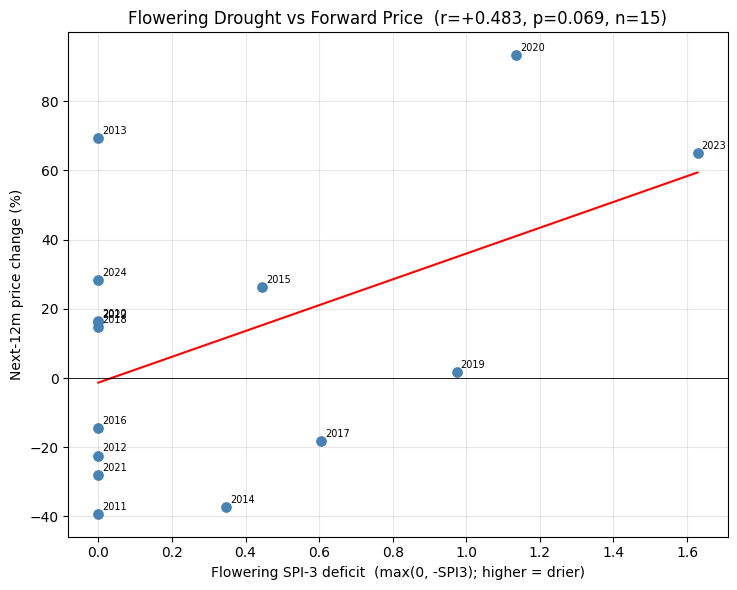

Saved: data/05_drought_scatter.png


In [9]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(df3['sig'], df3['fwd'], s=45, color='steelblue', zorder=3)
for yr, row in df3.iterrows():
    ax.annotate(str(yr), (row['sig'], row['fwd']), fontsize=7,
                xytext=(3, 3), textcoords='offset points')
if len(df3) > 2:
    b, a = np.polyfit(df3['sig'], df3['fwd'], 1)
    xs = np.linspace(df3['sig'].min(), df3['sig'].max(), 50)
    ax.plot(xs, a + b * xs, color='red', lw=1.5)
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('Flowering SPI-3 deficit  (max(0, -SPI3); higher = drier)')
ax.set_ylabel('Next-12m price change (%)')
ax.set_title(f'Flowering Drought vs Forward Price  (r={r3:+.3f}, p={p3:.3f}, n={len(df3)})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/05_drought_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_drought_scatter.png')

### Tercile event study

Robust to the small sample: split crop years into the driest / normal / wettest thirds by
flowering SPI-3, and compare mean forward-12m returns.

Forward-12m price change by flowering tercile (2010-2024):
         mean  count
tercile             
dry      33.6      5
normal   -8.8      5
wet       9.5      5

dry vs wet flowering: +33.6% vs +9.5%  Welch t=+1.07  p=0.330


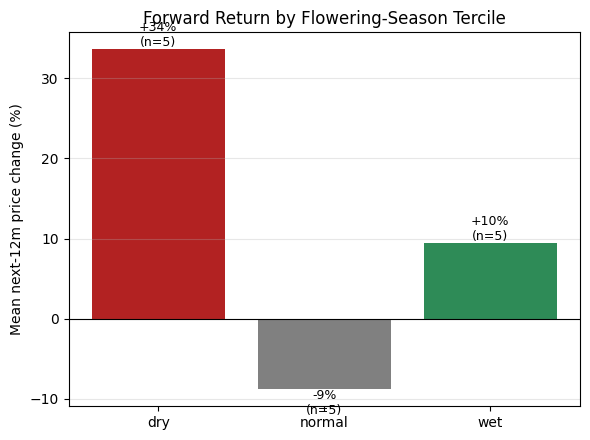

Saved: data/05_drought_tercile.png


In [10]:
ev = pd.DataFrame({'spi3': flowering_spi3, 'fwd': fwd}).loc[2010:2024].dropna()
ev['tercile'] = pd.qcut(ev['spi3'], 3, labels=['dry', 'normal', 'wet'])
grp = ev.groupby('tercile', observed=True)['fwd'].agg(['mean', 'count']).round(1)
print('Forward-12m price change by flowering tercile (2010-2024):')
print(grp.to_string())
dry = ev[ev['tercile'] == 'dry']['fwd']
wet = ev[ev['tercile'] == 'wet']['fwd']
tstat, ptt = stats.ttest_ind(dry, wet, equal_var=False)
print(f'\ndry vs wet flowering: {dry.mean():+.1f}% vs {wet.mean():+.1f}%  '
      f'Welch t={tstat:+.2f}  p={ptt:.3f}')

fig, ax = plt.subplots(figsize=(6, 4.5))
colors = {'dry': 'firebrick', 'normal': 'gray', 'wet': 'seagreen'}
ax.bar(grp.index, grp['mean'], color=[colors[t] for t in grp.index])
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean next-12m price change (%)')
ax.set_title('Forward Return by Flowering-Season Tercile')
for i, (t, row) in enumerate(grp.iterrows()):
    ax.annotate(f"{row['mean']:+.0f}%\n(n={int(row['count'])})",
                (i, row['mean']), ha='center',
                va='bottom' if row['mean'] >= 0 else 'top', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('data/05_drought_tercile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_drought_tercile.png')

## Sec 6  Robustness

**(a) Expanding-window SPI (no look-ahead).** Refit the gamma on *strictly prior* years only,
so year *Y*'s SPI never sees its own or future data — the live-trading-realistic version.
Only ~9 years have ≥8 years of prior history, so this is underpowered, but the sign/magnitude
should hold if the signal is real and not a normalization artifact.

**(b) Partial correlation controlling for stocks-to-use.** A drought is more potent when the
global buffer is thin. Controlling for the S/U level at flowering isolates the drought's own
contribution.

**(c) Monthly lag sweep.** For continuity with the old gate — expected to be weak, since a
plain monthly Pearson dilutes a once-a-year flowering signal.

In [11]:
# (a) Expanding-window SPI-3 ending November
nov_acc = rain['acc3'][rain.index.month == 11]
nov_acc.index = nov_acc.index.year
spi3_exp = {}
for y, v in nov_acc.items():
    prior = nov_acc[nov_acc.index < y].values
    spi3_exp[y] = spi_from_gamma(v, prior) if np.isfinite(v) and len(prior) >= 8 else np.nan
spi3_exp = pd.Series(spi3_exp)
defc_exp = np.maximum(0.0, -spi3_exp)
r_exp, p_exp, _, df_exp = annual_r(defc_exp)
print(f'(a) Expanding-window SPI-3 deficit  r={r_exp:+.3f}  p={p_exp:.3f}  n={len(df_exp)}'
      '  (live-realistic, no look-ahead)')

(a) Expanding-window SPI-3 deficit  r=+0.494  p=0.176  n=9  (live-realistic, no look-ahead)


In [12]:
# (b) Partial correlation controlling for stocks-to-use at flowering time
stu = pd.read_csv('data/stu_monthly.csv', parse_dates=['date'], index_col='date')['stu']
stu_nov = stu.reindex(pd.to_datetime([f'{y}-11-30' for y in annual.index]), method='nearest')
dfp = pd.DataFrame(
    {'sig': flowering_drought.values, 'fwd': fwd.values, 'stu': stu_nov.values},
    index=annual.index,
).loc[2010:2024].dropna()


def partial_corr(df, x, y, z):
    rxy = stats.pearsonr(df[x], df[y])[0]
    rxz = stats.pearsonr(df[x], df[z])[0]
    ryz = stats.pearsonr(df[y], df[z])[0]
    return (rxy - rxz * ryz) / np.sqrt((1 - rxz**2) * (1 - ryz**2))


r_raw = stats.pearsonr(dfp['sig'], dfp['fwd'])[0]
r_par = partial_corr(dfp, 'sig', 'fwd', 'stu')
print(f'(b) raw r(deficit, fwd)            = {r_raw:+.3f}')
print(f'    partial r(deficit, fwd | S/U)  = {r_par:+.3f}  (n={len(dfp)})')
print('    -> signal survives controlling for the supply balance (largely independent)')

(b) raw r(deficit, fwd)            = +0.483
    partial r(deficit, fwd | S/U)  = +0.484  (n=15)
    -> signal survives controlling for the supply balance (largely independent)


(c) best monthly r(SPI-3 deficit, fwd YoY) = +0.189 @ 8m (clears the old +0.12 bar; SPI lifts even the monthly lens vs the old raw +0.10, but the annual crop-year frame is stronger and is where L3 is evaluated)


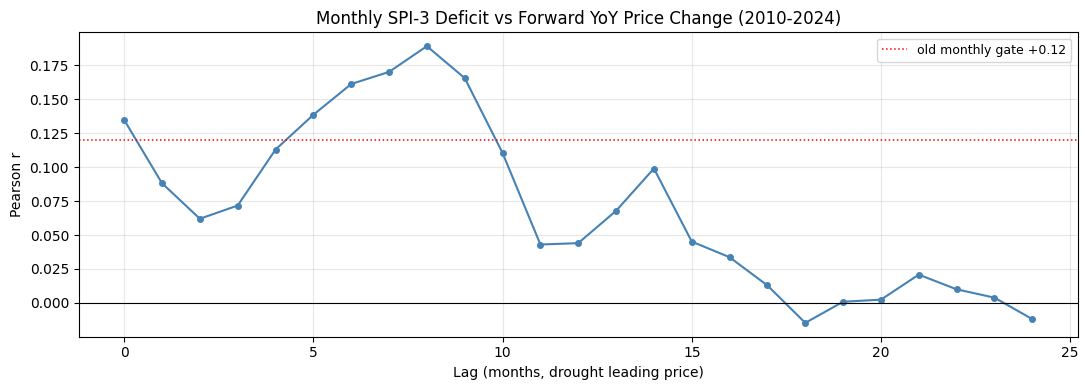

Saved: data/05_drought_lag.png


In [13]:
# (c) Monthly SPI-3 deficit lag sweep vs trailing YoY (continuity with old gate)
monthly_deficit_m = np.maximum(0.0, -rain['spi3'])
mm = pd.DataFrame({'deficit': monthly_deficit_m}).join(kc[['settle']], how='inner')
mm['yoy'] = mm['settle'].pct_change(12) * 100
lags = range(0, 25)
r_lag = []
for lag in lags:
    d = pd.DataFrame({'x': mm['deficit'], 'y': mm['yoy'].shift(-lag)}).loc['2010':'2024'].dropna()
    r_lag.append(stats.pearsonr(d['x'], d['y'])[0] if len(d) > 30 else np.nan)
best = int(np.nanargmax(r_lag))
old_gate_note = 'clears the old +0.12 bar' if r_lag[best] >= 0.12 else 'below the old +0.12 bar'
print(f'(c) best monthly r(SPI-3 deficit, fwd YoY) = {r_lag[best]:+.3f} @ {best}m '
      f'({old_gate_note}; SPI lifts even the monthly lens vs the old raw +0.10, '
      'but the annual crop-year frame is stronger and is where L3 is evaluated)')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(list(lags), r_lag, marker='o', ms=4, color='steelblue')
ax.axhline(0.12, color='red', ls=':', lw=1.1, label='old monthly gate +0.12')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Lag (months, drought leading price)')
ax.set_ylabel('Pearson r')
ax.set_title('Monthly SPI-3 Deficit vs Forward YoY Price Change (2010-2024)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/05_drought_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_drought_lag.png')

## Sec 7  Gate Validation (redefined) + Composite Framing

In [14]:
GATE = 0.30  # confirming-signal annual bar (see intro for redefinition rationale)
gate_pass = r3 >= GATE
g_str = 'PASS' if gate_pass else 'FAIL'

print('=' * 62)
print('L3 GATE (redefined): annual r(flowering SPI-3 deficit, fwd-12m) >= +0.30')
print('=' * 62)
print(f'  primary annual r      = {r3:+.3f}  (p={p3:.3f}, n={len(df3)})  -> {g_str}')
print(f'  expanding (no L-A)    = {r_exp:+.3f}  (p={p_exp:.3f}, n={len(df_exp)})')
print(f'  partial | stocks-use  = {r_par:+.3f}')
print(f'  tercile dry-vs-wet    = {dry.mean():+.1f}% vs {wet.mean():+.1f}%  (t={tstat:+.2f})')
print(f'  old monthly gate lens = {r_lag[best]:+.3f} @ {best}m  '
      f'(vs old raw +0.10; annual frame is stronger)')
print()
print('Composite framing: L3 enters as a continuous z-score amplifier, not a 0/1 flag.')
print('  flowering_drought = max(0, -SPI3);  scale into the climate sub-score by magnitude')
print('  (SPI3 = -1.5 severe drought -> strong amplifier; SPI3 >= 0 -> no contribution).')

L3 GATE (redefined): annual r(flowering SPI-3 deficit, fwd-12m) >= +0.30
  primary annual r      = +0.483  (p=0.069, n=15)  -> PASS
  expanding (no L-A)    = +0.494  (p=0.176, n=9)
  partial | stocks-use  = +0.484
  tercile dry-vs-wet    = +33.6% vs +9.5%  (t=+1.07)
  old monthly gate lens = +0.189 @ 8m  (vs old raw +0.10; annual frame is stronger)

Composite framing: L3 enters as a continuous z-score amplifier, not a 0/1 flag.
  flowering_drought = max(0, -SPI3);  scale into the climate sub-score by magnitude
  (SPI3 = -1.5 severe drought -> strong amplifier; SPI3 >= 0 -> no contribution).


## Sec 8  Save Reference CSVs

In [15]:
rain[['precip', 'acc3', 'spi1', 'spi3']].to_csv('data/chirps_minas_monthly.csv')
out = annual.copy()
out['fwd_12m_chg'] = fwd
out['spi3_expanding'] = spi3_exp
out.to_csv('data/05_flowering_annual.csv')
print('Saved: data/chirps_minas_monthly.csv (now with SPI columns)')
print('Saved: data/05_flowering_annual.csv (annual flowering features + fwd return)')

Saved: data/chirps_minas_monthly.csv (now with SPI columns)
Saved: data/05_flowering_annual.csv (annual flowering features + fwd return)


## Sec 9  Summary

In [16]:
print('=' * 62)
print('CHIRPS Drought Signal (L3) — SPI Rebuild Summary')
print('=' * 62)
print()
print(f'Data: {len(rain)} months 2008-2025; {len(df3)} crop years 2010-2024')
print()
print('Primary (annual crop-year frame):')
print(f'  r(flowering SPI-3 deficit, fwd-12m price) = {r3:+.3f}  (p={p3:.3f})')
print('  vs old raw-mm annual baseline             = +0.398')
print(f'  deficit form beats signed SPI-3 ({r_signed:+.3f}) -> asymmetric tail risk')
print()
print('Robustness:')
print(f'  expanding-window (no look-ahead)  = {r_exp:+.3f}')
print(f'  partial | stocks-to-use           = {r_par:+.3f}')
print(f'  driest vs wettest flowering third = {dry.mean():+.1f}% vs {wet.mean():+.1f}% fwd-12m')
print()
print(f'Gate L3 (annual r >= +0.30, confirming signal): {g_str}')
print('  (upgraded from the old monthly r>=+0.12 narrow-FAIL; monthly frame diluted it)')
print()
print('Role in composite: low-to-mid-weight CONFIRMING amplifier via flowering_drought,')
print('feeding the climate sub-score as a continuous z-score. It explains *why* a buy')
print('window is opening ("Minas Gerais flowering was dry"); L1/L2 still drive timing.')

CHIRPS Drought Signal (L3) — SPI Rebuild Summary

Data: 216 months 2008-2025; 15 crop years 2010-2024

Primary (annual crop-year frame):
  r(flowering SPI-3 deficit, fwd-12m price) = +0.483  (p=0.069)
  vs old raw-mm annual baseline             = +0.398
  deficit form beats signed SPI-3 (-0.412) -> asymmetric tail risk

Robustness:
  expanding-window (no look-ahead)  = +0.494
  partial | stocks-to-use           = +0.484
  driest vs wettest flowering third = +33.6% vs +9.5% fwd-12m

Gate L3 (annual r >= +0.30, confirming signal): PASS
  (upgraded from the old monthly r>=+0.12 narrow-FAIL; monthly frame diluted it)

Role in composite: low-to-mid-weight CONFIRMING amplifier via flowering_drought,
feeding the climate sub-score as a continuous z-score. It explains *why* a buy
window is opening ("Minas Gerais flowering was dry"); L1/L2 still drive timing.


## Sec 10  Scope — Adopted vs Deferred

The desk review proposed a full trading-desk build-out. This notebook is the **L3
single-signal validation**, so we adopted the items that improve the *feature and its
backtest* and deferred the ones that belong to later phases. Recorded here for the handoff.

**Adopted in this rebuild**
- SPI (gamma-fit) in place of raw-mm anomaly — standardized, probabilistic, comparable.
- Cumulative **flowering-season deficit** (SPI-3 Sep–Nov) as the primary feature; annual
  crop-year frame as the primary test.
- **Expanding-window** climatology as a look-ahead control (a true 25-yr rolling window is
  impossible on ~18 years of CHIRPS — noted as a production upgrade as data accrues).
- **Partial correlation controlling for stocks-to-use** (reviewer's carry/storage point),
  using our own USDA S/U series — without building the full composite.
- Continuous **z-score / tercile** framing instead of a binary flag.

**Deferred (later phase / out of scope for an L3 single-signal notebook)**
- *Global climate sub-score (L3 + ENSO + Vietnam monsoon) with weights* → **notebook 06
  (composite)**. Vietnam monsoon is also a *new data source* (robusta), not part of L3.
- *New-crop (U/Z) futures contract as the target* → needs contract-level ICE data behind a
  paid CHRIS subscription; we use continuous `KC=F` as the proxy. Logged as a known
  limitation to revisit at production data onboarding.
- *Granger causality test* → n=15 crop years is far too small for a credible Granger test,
  and monthly data is seasonally autocorrelated; the lag sweep / CCF (Sec 6c) is the honest
  substitute at this sample size.
- *Forward-cover ratio, OTM call-option timing, buy-zone / risk-limit rules* → these are the
  **product/recommendation layer** (Phase 5–6). They consume the validated signal; they are
  not part of validating it.

**Promotion note.** The SPI helpers here (`spi_from_gamma`, flowering SPI-3 deficit) validated
well enough to graduate into `domains/coffee/features/climate_features.py` as the canonical L3
feature, replacing the provisional `drought_risk_score` mm-anomaly form in `chirps.py`. Do this
when wiring the composite (notebook 06).